# MAGNET-ETAS Pipeline Output Analysis

This notebook analyzes the output of the MAGNET-ETAS pipeline, specifically comparing the original observed catalog (used for training/inversion) with the simulated catalog (continuation/forecast).

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
import datetime

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)


In [48]:
# --- CONFIGURATION ---
# Update this path to point to your specific model output directory
# Example: "../outputs/continuation/model_0140c718e2ccb257ef6f2d1fe1e8e9b47515afa4_69441e2bf0bdd271"
OUTPUT_DIR = "/home/neriberman/REPOS/etas_edits/outputs/continuation/model_0140c718e2ccb257ef6f2d1fe1e8e9b47515afa4_69441e2bf0bdd271"
OUTPUT_PATH = Path(OUTPUT_DIR)

print(f"Analyzing output in: {OUTPUT_PATH.resolve()}")


Analyzing output in: /home/neriberman/REPOS/etas_edits/outputs/continuation/model_0140c718e2ccb257ef6f2d1fe1e8e9b47515afa4_69441e2bf0bdd271


In [49]:
def load_catalog(path):
    """Loads a catalog CSV and parses the time column."""
    if not path.exists():
        print(f"Warning: File not found: {path}")
        return None
    
    df = pd.read_csv(path)
    # Standardize time parsing
    if 'time' in df.columns:
        df['time'] = pd.to_datetime(df['time'])
    return df

def load_json(path):
    """Loads a JSON config file."""
    if not path.exists():
        print(f"Warning: File not found: {path}")
        return {}
    with open(path, 'r') as f:
        return json.load(f)


In [50]:
# Load Data
original_catalog = load_catalog(OUTPUT_PATH / "original_catalog.csv")
simulated_catalog = load_catalog(OUTPUT_PATH / "simulated_catalog.csv")
inversion_config = load_json(OUTPUT_PATH / "inversion_config.json")
continuation_config = load_json(OUTPUT_PATH / "continuation_config.json")

# Filter Original Catalog (Optional: match inversion time window if needed)
# For now, we use the whole original catalog provided

if original_catalog is not None:
    print(f"Original Catalog: {len(original_catalog)} events")
    print(f"  Time Range: {original_catalog['time'].min()} to {original_catalog['time'].max()}")
    print(f"  Mag Range:  {original_catalog['magnitude'].min()} to {original_catalog['magnitude'].max()}")

if simulated_catalog is not None:
    print(f"Simulated Catalog: {len(simulated_catalog)} events")
    print(f"  Time Range: {simulated_catalog['time'].min()} to {simulated_catalog['time'].max()}")
    print(f"  Mag Range:  {simulated_catalog['magnitude'].min()} to {simulated_catalog['magnitude'].max()}")


Original Catalog: 266662 events
  Time Range: 1981-01-01 04:13:55 to 2021-12-31 23:38:36
  Mag Range:  -0.29 to 7.3
Simulated Catalog: 145 events
  Time Range: 2016-05-26 02:27:26.151987 to 2019-02-13 21:17:04.854250270
  Mag Range:  3.6 to 5.7


In [51]:
original_catalog


,id,latitude,longitude,time,magnitude
0,1,33.25517,-115.96750,1981-01-01 04:13:55,2.26
1,2,34.18600,-117.29733,1981-01-01 05:20:14,2.37
2,3,34.18433,-117.29600,1981-01-01 05:39:56,1.60
3,4,34.00633,-117.16200,1981-01-01 08:23:18,1.88
4,5,34.09367,-117.30517,1981-01-01 10:57:34,1.40
...,...,...,...,...,...
266657,266658,33.38267,-116.86733,2021-12-31 19:06:12,1.03
266658,266659,34.03983,-117.20350,2021-12-31 19:27:58,3.38
266659,266660,34.20850,-117.49767,2021-12-31 20:15:37,1.22
266660,266661,33.38317,-116.86250,2021-12-31 23:20:44,2.14


## 1. Cumulative Number of Events
Compare the event accumulation over time. The simulated catalog usually starts after the training period of the original catalog.

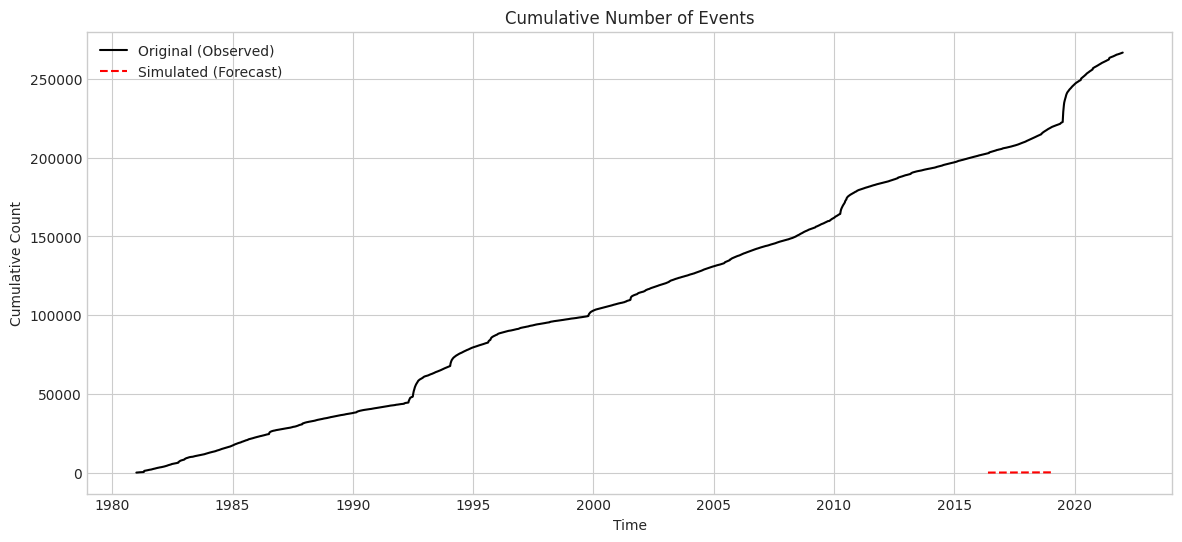

In [52]:
plt.figure(figsize=(14, 6))

if original_catalog is not None:
    # Sort by time just in case
    orig_sorted = original_catalog.sort_values('time')
    plt.plot(orig_sorted['time'], np.arange(len(orig_sorted)), label='Original (Observed)', color='black', linewidth=1.5)

if simulated_catalog is not None:
    sim_sorted = simulated_catalog.sort_values('time')
    
    # If simulated starts after original, we can offset the y-axis to make it continuous visually
    # or just plot it starting from 0 (if it's a new independent sequence)
    # Here, let's plot it accumulating FROM the end of the original count if appropriate
    y_offset = len(original_catalog) if original_catalog is not None else 0
    
    # Check if continuous in time
    is_continuation = False
    if original_catalog is not None:
        if sim_sorted['time'].min() > orig_sorted['time'].max():
            is_continuation = True
    
    label = 'Simulated (Forecast)'
    if is_continuation:
        plt.plot(sim_sorted['time'], np.arange(len(sim_sorted)) + y_offset, label=label, color='red', linewidth=1.5)
        # Add a dashed line connecting them
        plt.plot([orig_sorted['time'].iloc[-1], sim_sorted['time'].iloc[0]], [len(orig_sorted)-1, y_offset], 'k--', alpha=0.5)
    else:
        # Overlapping or separate -> Plot on secondary axis or just separate color starting at 0?
        # Let's plot starting at 0 for clarity if they overlap heavily, otherwise offset
        plt.plot(sim_sorted['time'], np.arange(len(sim_sorted)), label=label, color='red', linewidth=1.5, linestyle='--')

plt.title('Cumulative Number of Events')
plt.xlabel('Time')
plt.ylabel('Cumulative Count')
plt.legend()
plt.grid(True)
plt.show()


## 2. Magnitude-Frequency Distribution (Gutenberg-Richter)
Check if the simulated magnitudes follow the expected exponential distribution (log-linear).

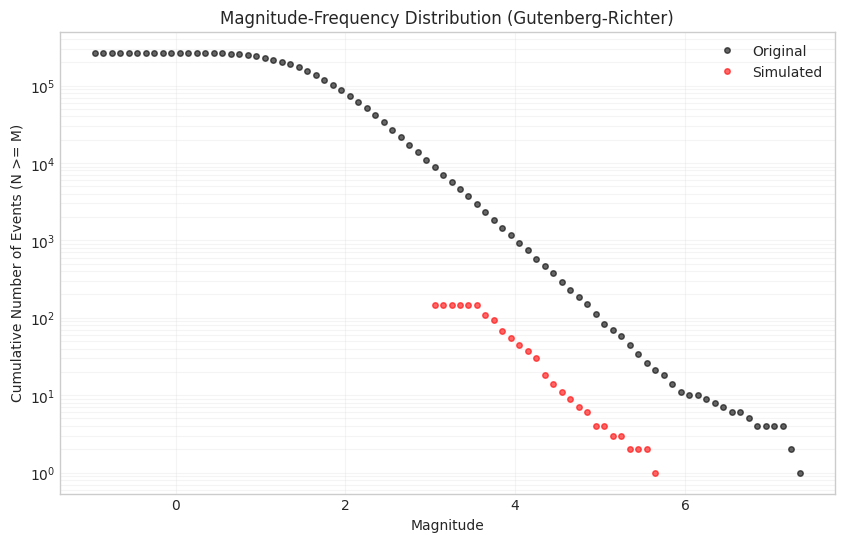

In [53]:
def plot_gr(catalog, label, color, ax):
    if catalog is None or len(catalog) == 0: return
    
    mags = catalog['magnitude']
    min_mag = np.floor(mags.min())
    max_mag = np.ceil(mags.max())
    bins = np.arange(min_mag, max_mag + 0.2, 0.1)
    
    hist, edges = np.histogram(mags, bins=bins)
    cum_hist = np.cumsum(hist[::-1])[::-1] # Cumulative from right
    
    centers = (edges[:-1] + edges[1:]) / 2
    
    # Filter out zeros for log plot
    valid = cum_hist > 0
    
    ax.semilogy(centers[valid], cum_hist[valid], 'o', label=label, color=color, markersize=4, alpha=0.6)

fig, ax = plt.subplots(figsize=(10, 6))

plot_gr(original_catalog, 'Original', 'black', ax)
plot_gr(simulated_catalog, 'Simulated', 'red', ax)

ax.set_xlabel('Magnitude')
ax.set_ylabel('Cumulative Number of Events (N >= M)')
ax.set_title('Magnitude-Frequency Distribution (Gutenberg-Richter)')
ax.legend()
ax.grid(True, which="both", ls="-", alpha=0.2)
plt.show()


## 3. Spatial Distribution
Compare the spatial footprint of observed vs simulated events.

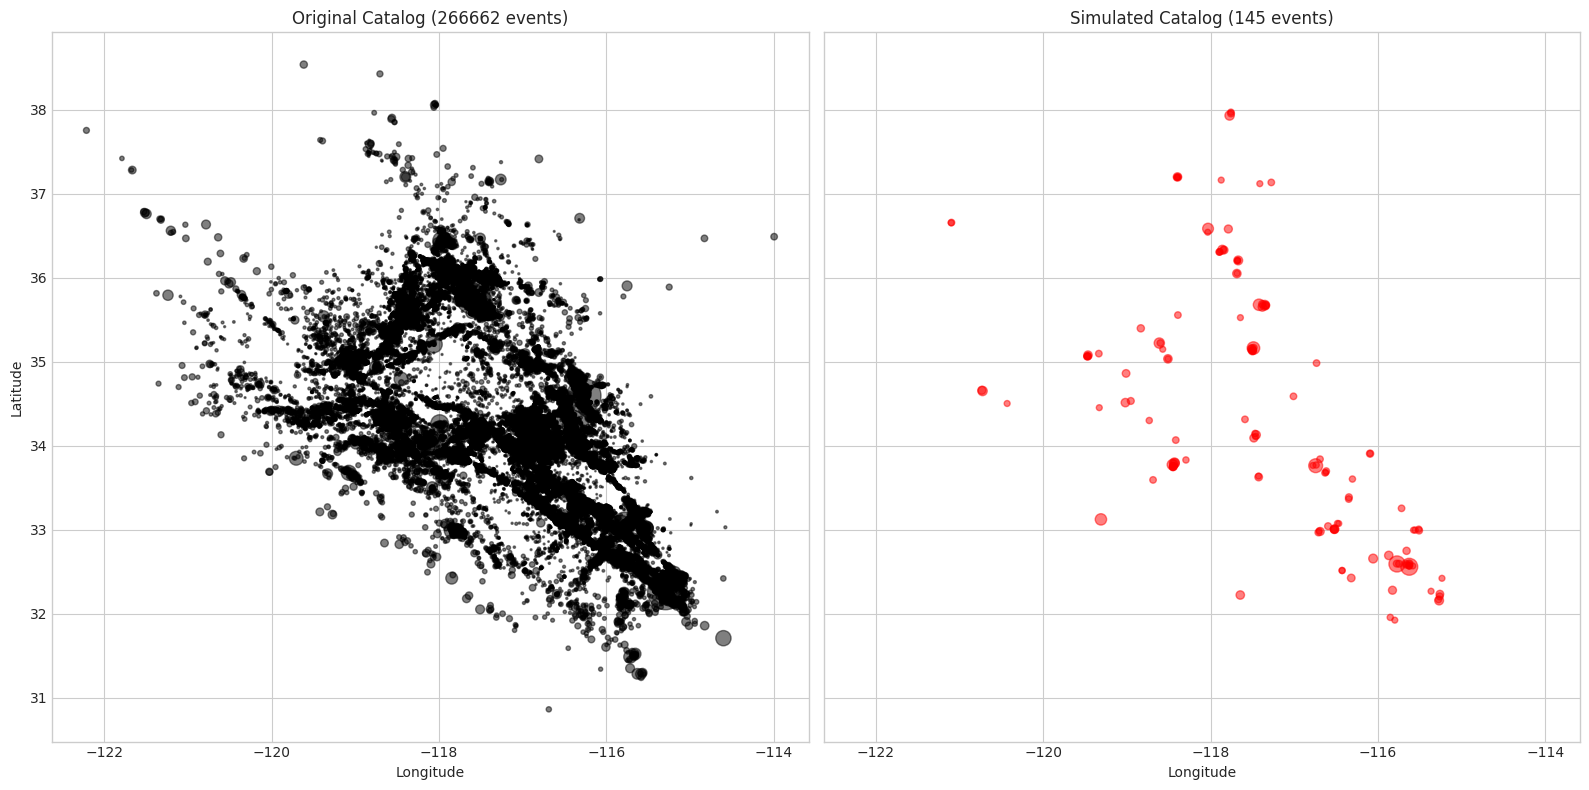

In [54]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), sharex=True, sharey=True)

if original_catalog is not None:
    ax1.scatter(original_catalog['longitude'], original_catalog['latitude'], 
                s=np.exp(original_catalog['magnitude'])/2, c='black', alpha=0.5, label='Events')
    ax1.set_title(f'Original Catalog ({len(original_catalog)} events)')
    ax1.set_xlabel('Longitude')
    ax1.set_ylabel('Latitude')
    ax1.grid(True)

if simulated_catalog is not None:
    # Color by time to see evolution if desired, or just magnitude size
    sc = ax2.scatter(simulated_catalog['longitude'], simulated_catalog['latitude'], 
                     s=np.exp(simulated_catalog['magnitude'])/2, c='red', alpha=0.5)
    ax2.set_title(f'Simulated Catalog ({len(simulated_catalog)} events)')
    ax2.set_xlabel('Longitude')
    ax2.grid(True)

plt.tight_layout()
plt.show()


## 4. Space-Time Plot (Latitude vs Time)
Visualize the migration or clustering of seismicity over time.

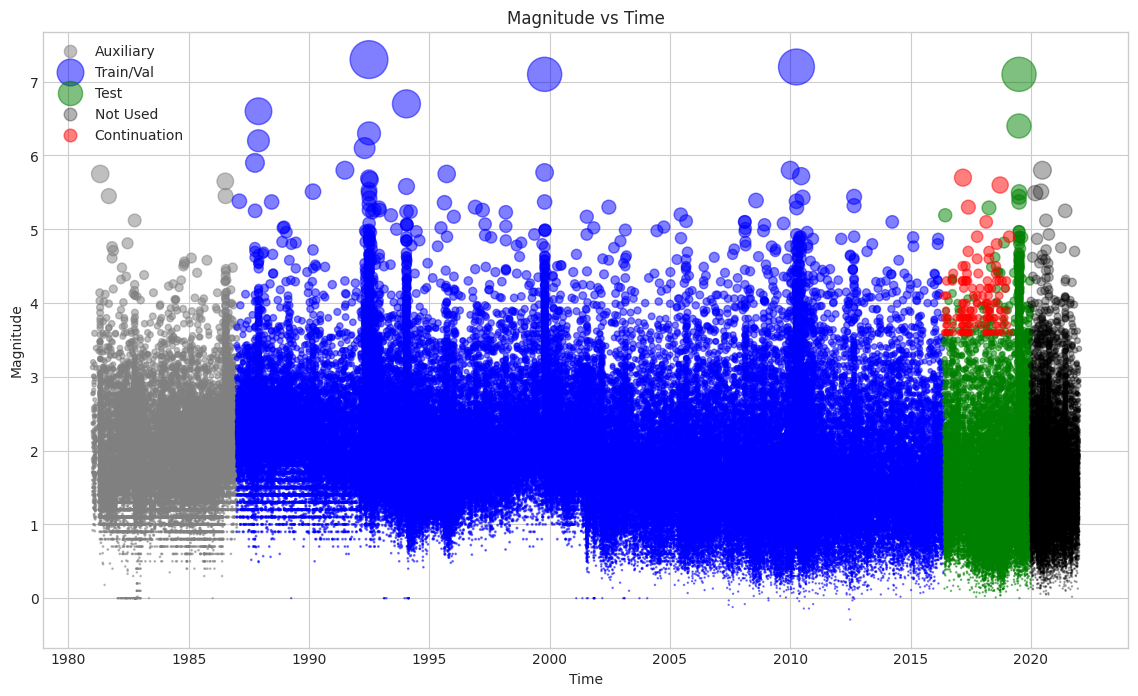

In [55]:
plt.figure(figsize=(14, 8))

# Get time configs
aux_start = pd.to_datetime(inversion_config.get('auxiliary_start'))
train_start = pd.to_datetime(inversion_config.get('timewindow_start'))
train_end = pd.to_datetime(inversion_config.get('timewindow_end'))
test_end = pd.to_datetime(inversion_config.get('testwindow_end'))

if original_catalog is not None:
    # Auxiliary
    mask_aux = (original_catalog['time'] >= aux_start) & (original_catalog['time'] < train_start)
    plt.scatter(original_catalog.loc[mask_aux, 'time'], original_catalog.loc[mask_aux, 'magnitude'], 
                s=np.exp(original_catalog.loc[mask_aux, 'magnitude'])/2, c='gray', alpha=0.5, label='Auxiliary')

    # Train/Validation
    mask_train = (original_catalog['time'] >= train_start) & (original_catalog['time'] < train_end)
    plt.scatter(original_catalog.loc[mask_train, 'time'], original_catalog.loc[mask_train, 'magnitude'], 
                s=np.exp(original_catalog.loc[mask_train, 'magnitude'])/2, c='blue', alpha=0.5, label='Train/Val')

    # Test and Unused
    if pd.notnull(test_end):
        mask_test = (original_catalog['time'] >= train_end) & (original_catalog['time'] < test_end)
        plt.scatter(original_catalog.loc[mask_test, 'time'], original_catalog.loc[mask_test, 'magnitude'], 
                    s=np.exp(original_catalog.loc[mask_test, 'magnitude'])/2, c='green', alpha=0.5, label='Test')
        
        mask_unused = (original_catalog['time'] >= test_end)
        plt.scatter(original_catalog.loc[mask_unused, 'time'], original_catalog.loc[mask_unused, 'magnitude'], 
                    s=np.exp(original_catalog.loc[mask_unused, 'magnitude'])/2, c='black', alpha=0.3, label='Not Used')
    else:
        mask_test = (original_catalog['time'] >= train_end)
        plt.scatter(original_catalog.loc[mask_test, 'time'], original_catalog.loc[mask_test, 'magnitude'], 
                    s=np.exp(original_catalog.loc[mask_test, 'magnitude'])/2, c='green', alpha=0.5, label='Test')

if simulated_catalog is not None:
    plt.scatter(simulated_catalog['time'], simulated_catalog['magnitude'], 
                s=np.exp(simulated_catalog['magnitude'])/2, c='red', alpha=0.5, label='Continuation')

plt.title('Magnitude vs Time')
plt.xlabel('Time')
plt.ylabel('Magnitude')
plt.legend()
plt.grid(True)
plt.show()


## 5. Inter-event Time Distribution
Analysis of the time intervals between consecutive events.

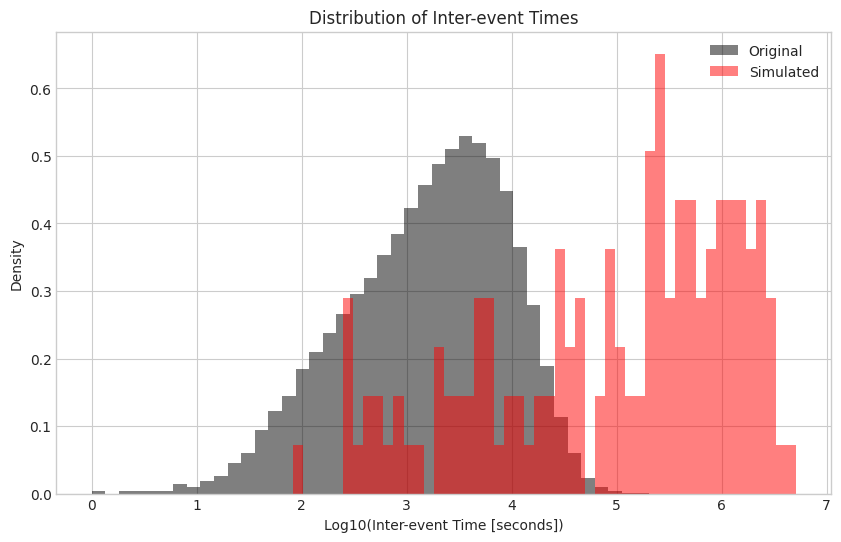

In [56]:
def get_interevent_times(catalog):
    if catalog is None or len(catalog) < 2:
        return np.array([])
    
    times = catalog.sort_values('time')['time']
    # Calculate differences in seconds
    dt = times.diff().dt.total_seconds().dropna()
    return dt[dt > 0] # Filter distinct timestamps

dt_orig = get_interevent_times(original_catalog)
dt_sim = get_interevent_times(simulated_catalog)

plt.figure(figsize=(10, 6))

if len(dt_orig) > 0:
    plt.hist(np.log10(dt_orig), bins=50, density=True, alpha=0.5, color='black', label='Original')

if len(dt_sim) > 0:
    plt.hist(np.log10(dt_sim), bins=50, density=True, alpha=0.5, color='red', label='Simulated')

plt.xlabel('Log10(Inter-event Time [seconds])')
plt.ylabel('Density')
plt.title('Distribution of Inter-event Times')
plt.legend()
plt.grid(True)
plt.show()


## 6. Daily Rate Comparison
Number of earthquakes per day.

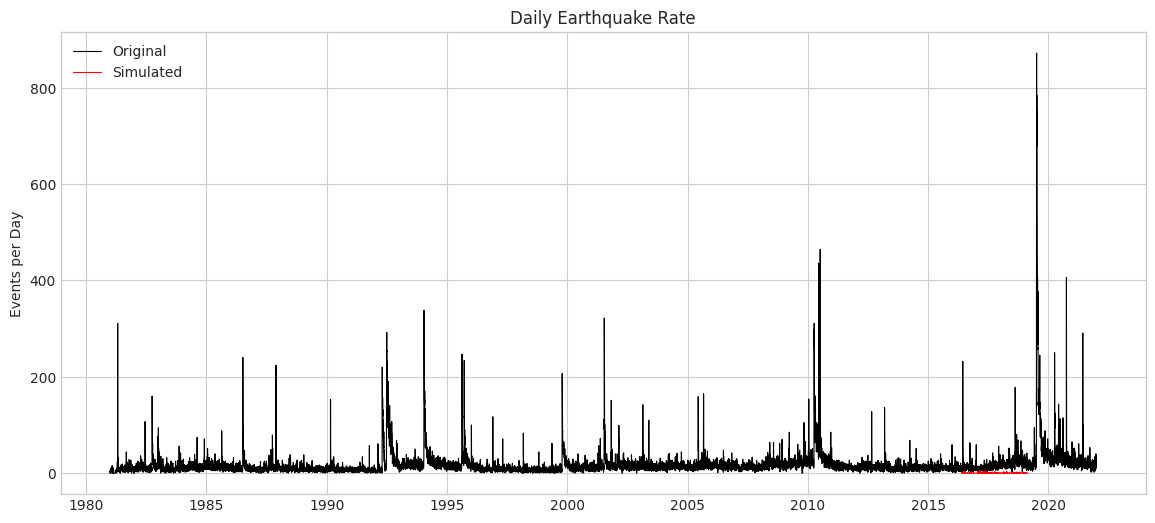

In [57]:
def plot_daily_rate(catalog, name, color, ax):
    if catalog is None: return
    # Resample to daily counts
    # Need to set index to time
    cat_time = catalog.set_index('time')
    daily_counts = cat_time.resample('D').size()
    
    ax.plot(daily_counts.index, daily_counts.values, color=color, label=name, linewidth=0.8)

fig, ax = plt.subplots(figsize=(14, 6))

plot_daily_rate(original_catalog, 'Original', 'black', ax)
plot_daily_rate(simulated_catalog, 'Simulated', 'red', ax)

ax.set_title('Daily Earthquake Rate')
ax.set_ylabel('Events per Day')
ax.legend()
ax.grid(True)
plt.show()
